In [1]:
import traci
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [2]:
SUMO_BINARY = "sumo"
SUMO_CONFIG = "simulation.sumocfg"
SIM_END = 4500
CONTROL_STEP = 15

NUM_LANES = 4

In [3]:
RAMPS = {
    "Ramp 1": {
        "loc": (1, 1),
        "x_range": (1400, 3600),
        "q0": 8196,
        "detectors": {
            "up":  {"ids": [f"det_a1_up_{i}"  for i in range(4)]+ ["det_a1_ramp_arr_0", "det_a1_ramp_arr_1"], "shift": 0},
            "down1": {"ids": [f"det_a1_dn1_{i}" for i in range(4)],   "shift": 30},
            "down2": {"ids": [f"det_a1_dn2_{i}" for i in range(4)],   "shift": 58},
        },
    },
    "Ramp 2": {
        "loc": (0, 1),
        "x_range": (2100, 4600),
        "q0": 7584,
        "detectors": {
            "up": {"ids": [f"det_a2_up_{i}"  for i in range(4)]+ ["det_a2_ramp_arr_0", "det_a2_ramp_arr_1"], "shift": 0},
            "down1": {"ids": [f"det_a2_dn1_{i}" for i in range(1, 5)], "shift": 29},
            "down2": {"ids": [f"det_a2_dn2_{i}" for i in range(4)],   "shift": 51},
        },
    },
    "Ramp 3": {
        "loc": (1, 0),
        "x_range": (1500, 3900),
        "q0": 7476,
        "detectors": {
            "up": {"ids": [f"det_a3_up_{i}"  for i in range(4)]+ ["det_a3_ramp_arr_0", "det_a3_ramp_arr_1"], "shift": 0},
            "down1": {"ids": [f"det_a3_dn1_{i}" for i in range(4)],   "shift": 22},
            "down2": {"ids": [f"det_a3_dn2_{i}" for i in range(1, 5)], "shift": 43},
        },
    },
    "Ramp 4": {
        "loc": (0, 0),
        "x_range": (1000, 3900),
        "q0": 6792,
        "detectors": {
            "up": {"ids": [f"det_a4_up_{i}"  for i in range(4)]+ ["det_a3_ramp_arr_0", "det_a3_ramp_arr_1"], "shift": 0},
            "down1": {"ids": [f"det_a4_dn1_{i}" for i in range(4)],   "shift": 39},
            "down2": {"ids": [f"det_a4_dn2_{i}" for i in range(4)],   "shift": 62},
        },
    },
}

In [4]:
# ----------- SIMULATION -----------

history = {
    "Ramp 1": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 2": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 3": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 4": {
            "up": [], "down1": [], "down2": []
        },
}

In [5]:
def getAllVehCounts(history):
    for ramp_name, item in RAMPS.items():
        up_ids = item['detectors']['up']['ids']
        down1_ids = item['detectors']['down1']['ids']
        down2_ids = item['detectors']['down2']['ids']

        up_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in up_ids])/4
        down1_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in down1_ids])/4
        down2_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in down2_ids])/4

        history[ramp_name]['up'].append(up_count)
        history[ramp_name]['down1'].append(down1_count)
        history[ramp_name]['down2'].append(down2_count)

    return history

In [6]:
ramp_times = [0] + list(np.arange(600, 3601, step=300)) + [SIM_END]

ramp_demands = {
    1:  [1700, 1700, 2175, 2175, 2175, 2175, 2175, 2175, 1400, 1400, 1400, 1400, 1400],
    2:  [1030, 1030, 1243, 1243, 1243, 1243, 1243, 1080, 960, 960, 960, 960, 960],
    3:  [1103, 1103, 1292, 1292, 1292, 1292, 1292, 1103, 1086, 1086, 1086, 1046, 1046],
    4:  [1313, 1313, 2221, 2221, 2221, 2221, 2221, 1313, 1300, 1300, 1275, 1250, 1250]
}

ramp_demands = {
    1:  [500]*13,
    2:  [500]*13,
    3:  [500]*13,
    4:  [2100]*13
}

In [7]:
# bonus = 500

# ramp_demands[1] = np.asarray(ramp_demands[1])
# ramp_demands[2] = np.asarray(ramp_demands[2]) + bonus * 0
# ramp_demands[3] = np.asarray(ramp_demands[3]) + bonus * 0
# ramp_demands[4] = np.asarray(ramp_demands[4]) + bonus * 3

In [8]:
def get_ramp1_flow(t):
    return np.interp(t, ramp_times, ramp_demands[1])

def get_ramp2_flow(t):
    return np.interp(t, ramp_times, ramp_demands[2])

def get_ramp3_flow(t):
    return np.interp(t, ramp_times, ramp_demands[3])

def get_ramp4_flow(t):
    return np.interp(t, ramp_times, ramp_demands[4])

In [9]:
routes = {
    1:  ["ramp1_to_end", "ramp1_to_off1", "ramp1_to_off2", "ramp1_to_off3", "ramp1_to_off4"],
    2:  ["ramp2_to_end", "ramp2_to_off3", "ramp2_to_off4"],
    3:  ["ramp3_to_end", "ramp3_to_off4"],
    4:  ["ramp4_to_end"]
}

probs = {
    1:  [0.6, 0.1, 0.1, 0.1, 0.1],
    2:  [0.8, 0.1, 0.1],
    3:  [0.9, 0.1],
    4:  [1.0]
}

probs = {
    1:  [0.5, 0.2, 0.1, 0.1, 0.1],
    2:  [0.6, 0.2, 0.2],
    3:  [0.7, 0.3],
    4:  [1.0]
}

In [10]:
def insertRampVehicles(rampIndex, t):
    fncs = {1: get_ramp1_flow, 2: get_ramp2_flow, 3: get_ramp3_flow, 4: get_ramp4_flow}

    get_flow_fnc = fncs[rampIndex]

    V = get_flow_fnc(t)
    p = V / (3600 * 2)

    for lane in range(2):
        if np.random.random() < p:
            route = np.random.choice(routes[rampIndex], p=probs[rampIndex])

            traci.vehicle.add(f"ramp{rampIndex}_{t}_{lane}", route, typeID="car_ramp",
                departLane="best", departPos="free", departSpeed="random")

In [11]:
def insertVehicles():
    t = traci.simulation.getTime()

    for i in range(4):
        insertRampVehicles(i+1, t)

In [ ]:
traci.start([SUMO_BINARY, "-c", SUMO_CONFIG, "--no-step-log", "true", "--no-warnings"])

times = []

for i in tqdm(range(SIM_END)):
    insertVehicles()

    # if i % CONTROL_STEP == 0 and i != 0:
    history = getAllVehCounts(history)

    times.append(i)

    traci.simulationStep()

traci.close()

 75%|███████▍  | 3361/4500 [00:52<00:21, 52.08it/s]

# Figure 12

In [ ]:
def getFlow(counts):
    counts = np.asarray(counts, dtype=float)

    flow = np.zeros(len(counts))
    half = FLOW_WINDOW // 2

    for i in range(len(counts)):
        s = max(0, i - half)
        e = min(len(counts), i + half + 1)

        window_sum = np.sum(counts[s:e])
        window_length = e - s

        # Convert vehicles/second to vehicles/hour
        flow[i] = (window_sum / window_length) * 3600

    return flow*4

FLOW_WINDOW = 300

ramp1_flow = getFlow(history['Ramp 1']['down1'])
ramp2_flow = getFlow(history['Ramp 2']['down1'])
ramp3_flow = getFlow(history['Ramp 3']['down1'])
ramp4_flow = getFlow(history['Ramp 4']['down1'])

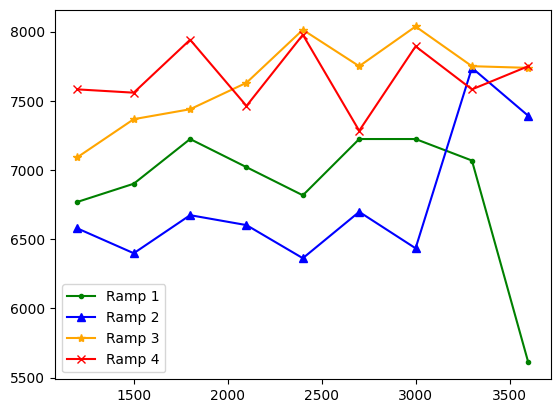

In [ ]:
times_to_plot = np.arange(1200, 3601, step=300)
x = np.asarray(times)[times_to_plot]

y_ramp1 = ramp1_flow[x]
y_ramp2 = ramp2_flow[x]
y_ramp3 = ramp3_flow[x]
y_ramp4 = ramp4_flow[x]

plt.plot(x, y_ramp1, color="g", marker=".", label="Ramp 1")
plt.plot(x, y_ramp2, color="b", marker="^", label="Ramp 2")
plt.plot(x, y_ramp3, color="orange", marker="*", label="Ramp 3")
plt.plot(x, y_ramp4, color="r", marker="x", label="Ramp 4")

plt.legend()
plt.show()

# Figure 13

In [ ]:
def getPlotValues(cfg, ramp_history, times):
    SHIFT_DN1 = cfg['detectors']['down1']['shift']
    SHIFT_DN2 = cfg['detectors']['down2']['shift']

    plot_values = {
        'up': {'x': times[::15], 'y': []},
        'down1': {'x': (times-SHIFT_DN1)[::15], 'y': []},
        'down2': {'x': (times-SHIFT_DN2)[::15], 'y': []},
    }

    q0 = cfg['q0'] / 3600.0 / NUM_LANES

    up_cumsum = np.cumsum(np.asarray(ramp_history['up']))
    down1_cumsum = np.cumsum(np.asarray(ramp_history['down1']))
    down2_cumsum = np.cumsum(np.asarray(ramp_history['down2']))

    up_y = up_cumsum - (q0 * times)
    down1_y = down1_cumsum - (q0 * times)
    down2_y = down2_cumsum - (q0 * times)

    # Calculate modified cumulative arrivals N'(x,t)
    plot_values['up']['y'] = up_y[::15]
    plot_values['down1']['y'] = down1_y[::15]
    plot_values['down2']['y'] = down2_y[::15]

    return plot_values

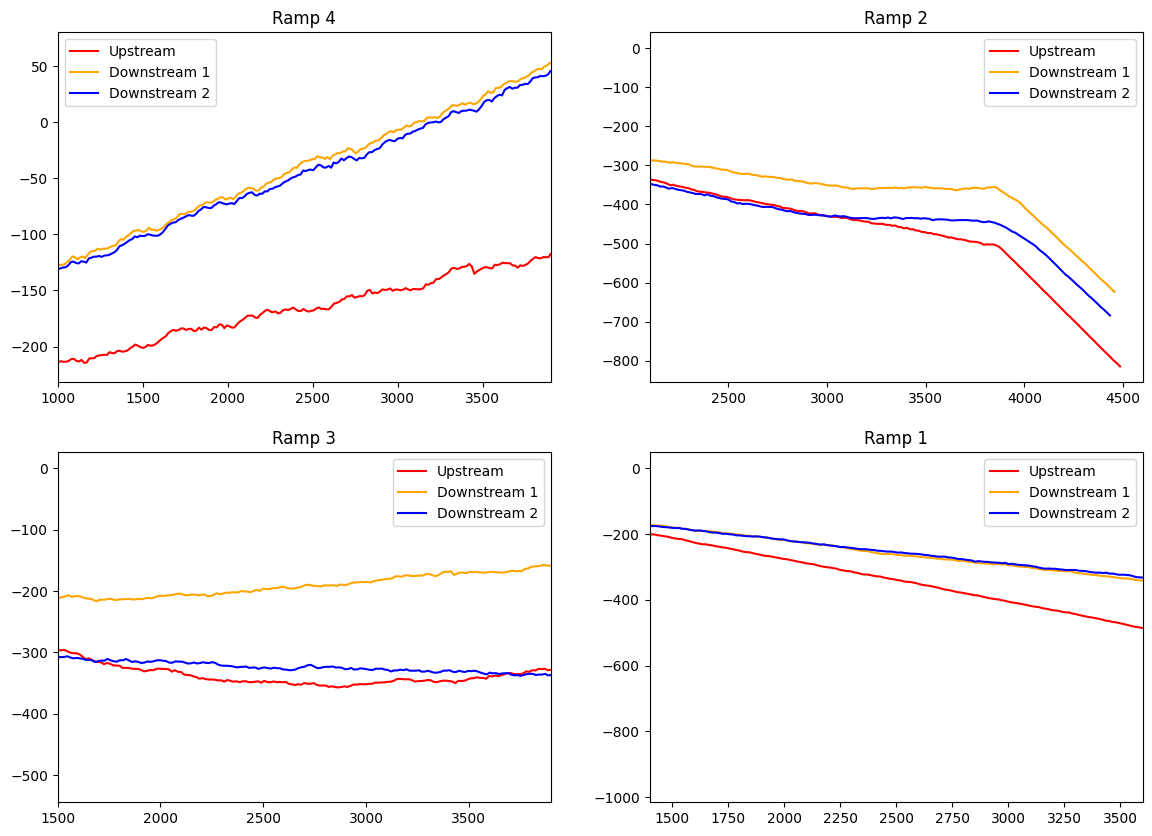

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ramp_name, cfg in RAMPS.items():
    row, col = cfg["loc"]

    ax = axs[row,col]

    plot_values = getPlotValues(cfg, history[ramp_name], np.asarray(times))

    # Shift the downstream curves to the left (backward in time)
    ax.plot(plot_values['up']['x'], plot_values['up']['y'], color="r", label="Upstream")
    ax.plot(plot_values['down1']['x'], plot_values['down1']['y'], color="orange", label="Downstream 1")
    ax.plot(plot_values['down2']['x'], plot_values['down2']['y'], color="b", label="Downstream 2")

    ax.set_xlim(cfg['x_range'])
    ax.set_title(ramp_name)

    ax.legend()

os.makedirs("plots", exist_ok=True)
plt.savefig(os.path.join("plots", "fig_13.png"))
plt.show()